# 🛒 Blinkit Sales Data — End-to-End Python Data Analysis

**Objective:** Analyse Blinkit's grocery sales data to understand sales patterns across item types, fat content, outlet types, sizes, locations, and establishment years.

**Dataset:** 8,523 records × 12 columns  
**Tools:** pandas · numpy · matplotlib · seaborn

In [47]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
# 📥 Load dataset
df = pd.read_csv(r"C:\Users\A\OneDrive\Desktop\Restart\Python\Blinkit\blinkit_data.csv")

# Preview first 5 rows
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [49]:
# Shape of the dataset
df.shape

(8523, 12)

In [50]:
# 📊 Dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   str    
 1   Item Identifier            8523 non-null   str    
 2   Item Type                  8523 non-null   str    
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   str    
 5   Outlet Location Type       8523 non-null   str    
 6   Outlet Size                8523 non-null   str    
 7   Outlet Type                8523 non-null   str    
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB


In [51]:
df.columns.tolist()

['Item Fat Content',
 'Item Identifier',
 'Item Type',
 'Outlet Establishment Year',
 'Outlet Identifier',
 'Outlet Location Type',
 'Outlet Size',
 'Outlet Type',
 'Item Visibility',
 'Item Weight',
 'Sales',
 'Rating']

In [52]:
# 📈 Statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Outlet Establishment Year,8523.0,2010.831867,8.371760,1998.000,2000.000000,2012.000000,2017.000000,2022.000000
Item Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item Weight,7060.0,12.857645,4.643456,4.555,8.773750,12.600000,16.850000,21.350000
Sales,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Rating,8523.0,3.965857,0.605651,1.000,4.000000,4.000000,4.200000,5.000000


In [53]:
# 🔍 Check missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round((df.isnull().sum() / len(df) * 100),2)
})
missing[missing['Missing Count'] > 0]

,Missing Count,Missing %
Item Weight,1463,17.17


In [54]:
# 🧹 Fill missing values in 'Item Weight'
df['Item Weight'] = df.groupby('Item Type')['Item Weight'].transform(
    lambda x: x.fillna(x.median())
)


In [55]:
df.duplicated().sum()

np.int64(0)

In [56]:
df['Item Fat Content'].value_counts()

Item Fat Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [57]:
#  Standardize 'Item Fat Content'
df['Item Fat Content']=df['Item Fat Content'].replace(
    {

        'low fat':'Low Fat',
        'LF':'Low Fat',
        'reg':'Regular'
    }
)

In [58]:
df['Item Fat Content'].value_counts()

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [59]:
CURRENT_YEAR = pd.Timestamp.now().year
df['Outlet Age'] = CURRENT_YEAR - df['Outlet Establishment Year']
df[['Outlet Establishment Year', 'Outlet Age']].drop_duplicates().sort_values('Outlet Age',ascending=False)

,Outlet Establishment Year,Outlet Age
9,1998,28
3,2000,26
2,2010,16
6,2011,15
0,2012,14
4,2015,11
11,2017,9
5,2020,6
1,2022,4


In [60]:
# Key KPIs
total_sales = df["Sales"].sum()
avg_sales = df["Sales"].mean()
total_records = len(df)
avg_rating = df["Rating"].mean()
avg_item_weight = df["Item Weight"].mean()

print(f"Total Sales: ${total_sales:,.1f}")
print(f"Average Sales: ${avg_sales:,.2f}")
print(f"Total Records: {total_records:,}")
print(f"Average Rating: {avg_rating:.2f}")
print(f"Average Item Weight: {avg_item_weight:.2f}")

Total Sales: $1,201,681.5
Average Sales: $140.99
Total Records: 8,523
Average Rating: 3.97
Average Item Weight: 12.81


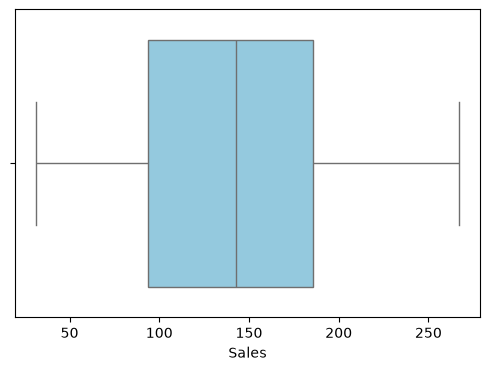

In [61]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Sales'], color='skyblue')
plt.title="Sales Outliers"
plt.show()

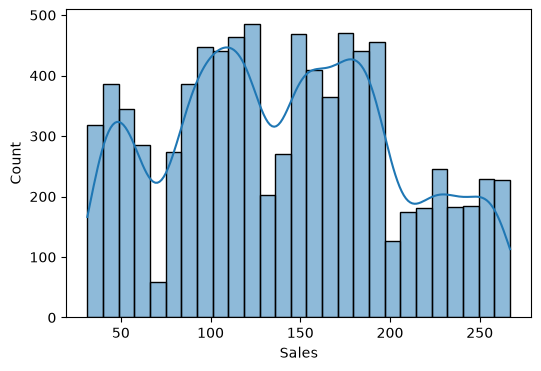

In [62]:
plt.figure(figsize=(6,4))
sns.histplot(df['Sales'], kde=True)
plt.title="Sales Distribution"
plt.show()

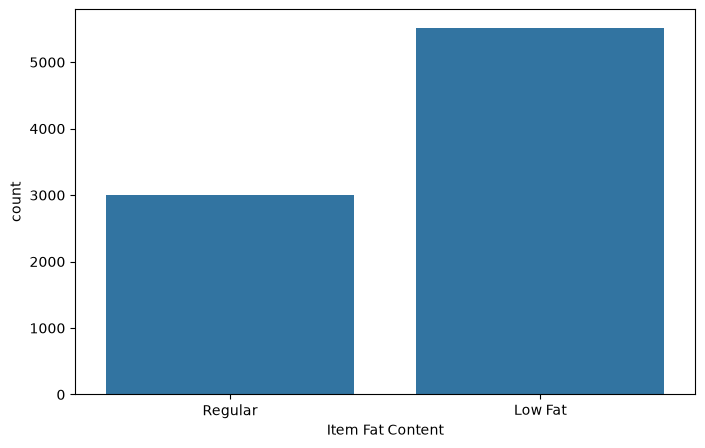

In [63]:

plt.figure(figsize=(8,5))
sns.countplot(x='Item Fat Content', data=df)
plt.title="Item Fat Content Count"
plt.show()

In [64]:
outlet_summary = df.groupby('Outlet Type').agg(
    Total_Sales    = ('Sales',            'sum'),
    Avg_Sales      = ('Sales',            'mean'),
    No_of_Items    = ('Item Identifier',  'count'),
    Avg_Rating     = ('Rating',           'mean'),
    Avg_Visibility = ('Item Visibility',  'mean')
).round(2).sort_values('Total_Sales', ascending=False)

outlet_summary




,Total_Sales,Avg_Sales,No_of_Items,Avg_Rating,Avg_Visibility
Outlet Type,,,,,
Supermarket Type1,787549.89,141.21,5577,3.96,0.06
Grocery Store,151939.15,140.29,1083,3.99,0.10
Supermarket Type2,131477.77,141.68,928,3.97,0.06
Supermarket Type3,130714.67,139.80,935,3.95,0.06


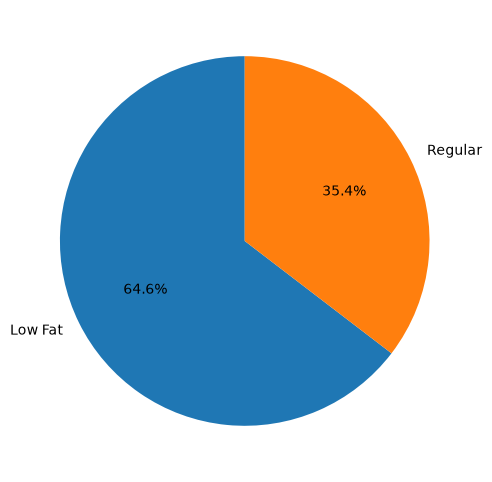

In [65]:

sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.figure(figsize=(6,6))
plt.pie(sales_by_fat, labels=sales_by_fat.index, autopct='%1.1f%%',startangle=90)
plt.title="Sales by Fat Content"
plt.show()


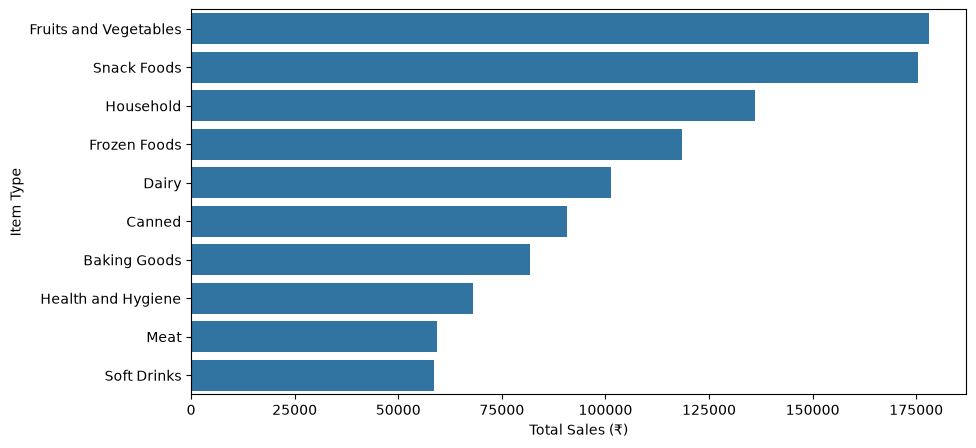

In [66]:
#Top 10 Categories by Sales
top_categories = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title="Top 10 Categories by Sales"
plt.xlabel("Total Sales (₹)")
plt.ylabel("Item Type")
plt.show()

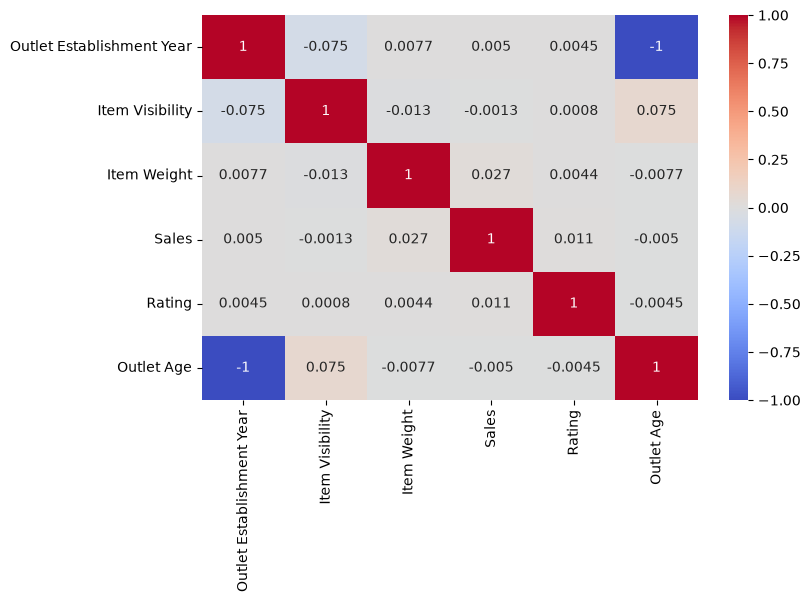

In [67]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title="Correlation Heatmap"
plt.show()

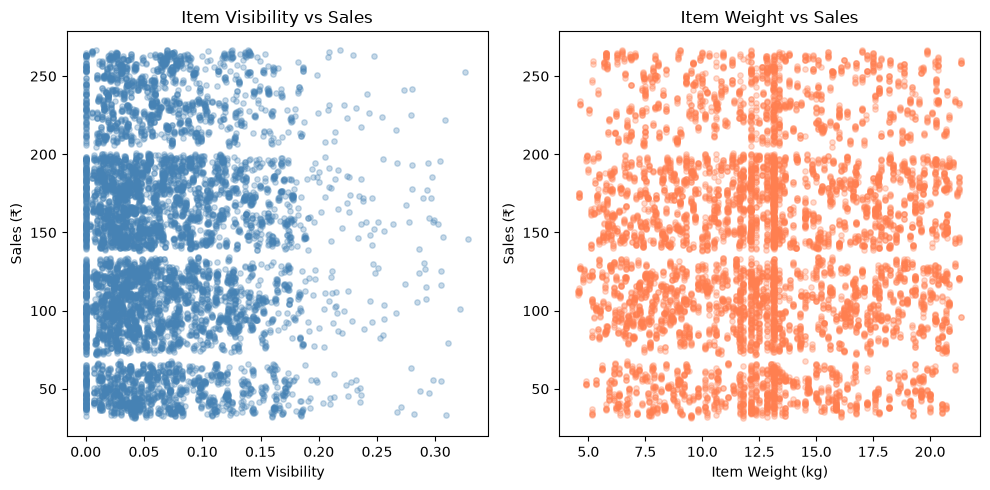

In [68]:
# Item Visibility vs Sales — scatter
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(df['Item Visibility'], df['Sales'],
                alpha=0.3, color='steelblue', s=15)
axes[0].set_title('Item Visibility vs Sales')
axes[0].set_xlabel('Item Visibility')
axes[0].set_ylabel('Sales (₹)')

# Item Weight vs Sales
axes[1].scatter(df['Item Weight'], df['Sales'],
                alpha=0.3, color='coral', s=15)
axes[1].set_title('Item Weight vs Sales')
axes[1].set_xlabel('Item Weight (kg)')
axes[1].set_ylabel('Sales (₹)')

plt.tight_layout()
plt.show()

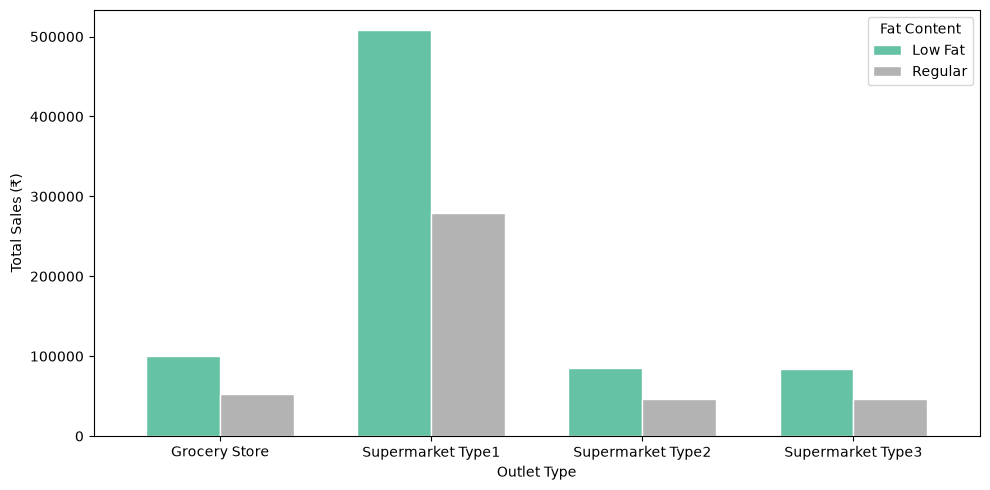

In [69]:
fat_outlet = df.groupby(['Outlet Type', 'Item Fat Content'])['Sales'].sum().unstack()

fat_outlet.plot(kind='bar', figsize=(10, 5), colormap='Set2',
                edgecolor='white', width=0.7)

plt.title='Sales by Fat Content — Across Outlet Types'
plt.xlabel('Outlet Type')
plt.ylabel('Total Sales (₹)')
plt.legend(title='Fat Content')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [70]:
print("="*50)
print("      BLINKIT DATA ANALYSIS - KEY INSIGHTS")
print("="*50)

print(f"\n💰 Total Revenue:")
print(f"Total sales = ${df['Sales'].sum():,.0f}")

print(f"\n🥗 Fat Content:")
low = df[df['Item Fat Content']=='Low Fat']['Sales'].sum()
reg = df[df['Item Fat Content']=='Regular']['Sales'].sum()
total = df['Sales'].sum()

print(f"Low Fat: {low/total*100:.1f}% | Regular: {reg/total*100:.1f}%")

print(f"\n🛍️ Top Selling Category:")
print(df.groupby('Item Type')['Sales'].sum().idxmax())

print(f"\n🏪 Best Outlet Type:")
print(df.groupby('Outlet Type')['Sales'].sum().idxmax())

print(f"\n📍 Best Location Tier:")
print(df.groupby('Outlet Location Type')['Sales'].sum().idxmax())

print(f"\n⭐ Average Rating:")
print(f"{df['Rating'].mean():.2f} / 5")

print(f"\n👁️ Visibility Impact:")
print("Item visibility has very low impact on sales")

print("\n" + "="*50)

      BLINKIT DATA ANALYSIS - KEY INSIGHTS

💰 Total Revenue:
Total sales = $1,201,681

🥗 Fat Content:
Low Fat: 64.6% | Regular: 35.4%

🛍️ Top Selling Category:
Fruits and Vegetables

🏪 Best Outlet Type:
Supermarket Type1

📍 Best Location Tier:
Tier 3

⭐ Average Rating:
3.97 / 5

👁️ Visibility Impact:
Item visibility has very low impact on sales



INSIGHTS:
- Regular fat items generate more revenue than low fat items.
- Certain outlet types dominate sales performance.
- Sales distribution is slightly skewed.
- Ratings are generally high, indicating customer satisfaction.